# Visualizações de Churn

Este notebook usa o arquivo `data/churn_predictions.csv` para explorar visualmente as probabilidades de churn, faixas de risco e ações recomendadas. A ideia aqui é substituir o dashboard no Power BI por análises e gráficos feitos em Python.


## 1. Importação das bibliotecas

Neste bloco vamos importar as bibliotecas de análise e visualização. `pandas` será usado para manipular a base, enquanto `matplotlib` e `seaborn` serão usados para criar os gráficos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Carregamento do CSV final

Aqui vamos carregar o CSV gerado pelo `src/predict.py`. Esse arquivo já contém a probabilidade de churn (`churn_prob`), a faixa de risco (`risk_band`) e a ação recomendada (`recommended_action`).


In [2]:
df = pd.read_csv("../data/churn_predictions.csv")
df.head()

,customerID,churn_real,churn_prob,risk_band,recommended_action,risk_band_order,tenure_group,tenure_group_order,monthly_charge_band,monthly_charge_band_order,Contract,tenure,MonthlyCharges,InternetService,PaymentMethod
0,7590-VHVEG,0,0.7670,High,Direct retention action,3,0-12,1,Low,1,Month-to-month,1,29.85,DSL,Electronic check
1,5575-GNVDE,0,0.1008,Low,No immediate action,1,25-48,3,Medium,2,One year,34,56.95,DSL,Mailed check
2,3668-QPYBK,1,0.5562,Medium,Light action / monitoring,2,0-12,1,Medium,2,Month-to-month,2,53.85,DSL,Mailed check
3,7795-CFOCW,0,0.0563,Low,No immediate action,1,25-48,3,Medium,2,One year,45,42.30,DSL,Bank transfer (automatic)
4,9237-HQITU,1,0.8733,High,Direct retention action,3,0-12,1,High,3,Month-to-month,2,70.70,Fiber optic,Electronic check


Esse primeiro contato com a base serve para confirmar que o CSV foi lido corretamente e que as colunas principais estão disponíveis para criar as visualizações. Se `churn_prob`, `risk_band` e `recommended_action` aparecem na amostra, o arquivo está pronto para a exploração visual.


## 3. Conferência inicial dos dados

Antes de criar gráficos, vamos conferir o tamanho da base, as colunas disponíveis e a distribuição das faixas de risco. Isso evita montar visualizações em cima de dados incompletos ou com nomes de colunas diferentes do esperado.


In [3]:
print(df.shape)
print(df.columns.tolist())
df["risk_band"].value_counts()

(7043, 15)
['customerID', 'churn_real', 'churn_prob', 'risk_band', 'recommended_action', 'risk_band_order', 'tenure_group', 'tenure_group_order', 'monthly_charge_band', 'monthly_charge_band_order', 'Contract', 'tenure', 'MonthlyCharges', 'InternetService', 'PaymentMethod']


risk_band
Low       4456
High      1705
Medium     882
Name: count, dtype: int64

Essa conferência ajuda a validar se a base tem o tamanho esperado e se as faixas de risco foram geradas corretamente. A distribuição de `risk_band` também dá uma primeira noção do volume de clientes que podem precisar de ação direta.


## 4. Distribuição das faixas de risco

Este gráfico mostra quantos clientes estão em cada faixa de risco. Ele ajuda a entender o volume de clientes que exigem ação direta, monitoramento ou nenhuma ação imediata.


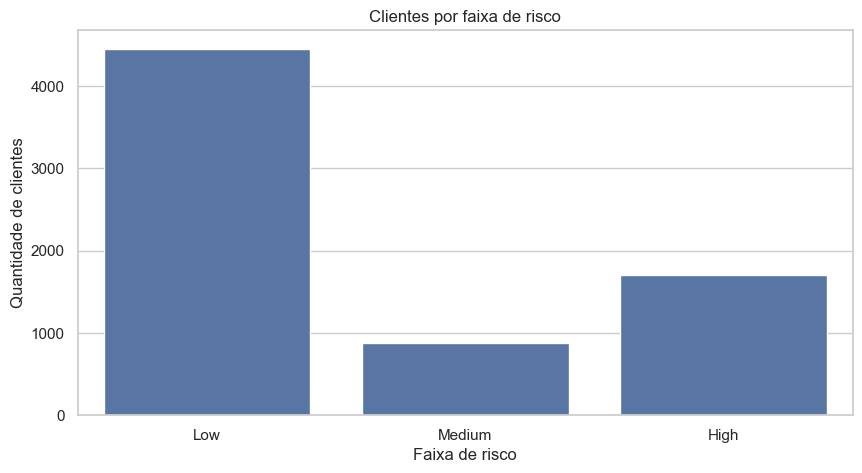

In [4]:
risk_order = ["Low", "Medium", "High"]

ax = sns.countplot(data=df, x="risk_band", order=risk_order)
ax.set_title("Clientes por faixa de risco")
ax.set_xlabel("Faixa de risco")
ax.set_ylabel("Quantidade de clientes")
plt.show()

Esse gráfico mostra rapidamente como os clientes estão distribuídos entre baixo, médio e alto risco. Ele funciona como uma visão geral do problema: se a faixa `High` for grande, há muitos clientes para priorizar em ações de retenção.


## 5. Probabilidade média por tempo de permanência

Aqui vamos comparar a probabilidade média de churn por faixa de `tenure`. A expectativa é verificar se clientes mais novos concentram maior risco de cancelamento.


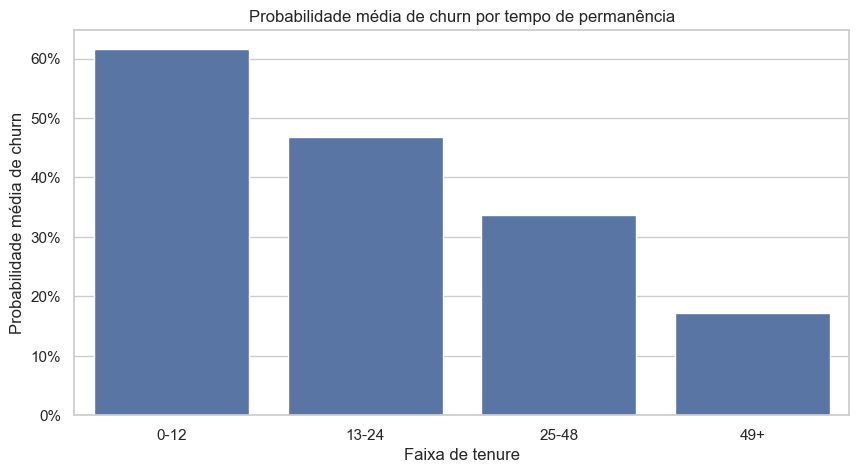

In [5]:
tenure_order = ["0-12", "13-24", "25-48", "49+"]

tenure_prob = (
    df.groupby("tenure_group", observed=True)["churn_prob"]
    .mean()
    .reindex(tenure_order)
    .reset_index()
)

ax = sns.barplot(data=tenure_prob, x="tenure_group", y="churn_prob")
ax.set_title("Probabilidade média de churn por tempo de permanência")
ax.set_xlabel("Faixa de tenure")
ax.set_ylabel("Probabilidade média de churn")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.show()

Ao comparar a probabilidade média por faixa de permanência, fica mais fácil observar se clientes novos apresentam maior risco de churn. Esse padrão costuma ser importante para definir campanhas de onboarding ou acompanhamento nos primeiros meses.


## 6. Risco por tipo de contrato

Este gráfico cruza `Contract` com `risk_band`. Ele ajuda a verificar se contratos mensais concentram mais clientes em alto risco.


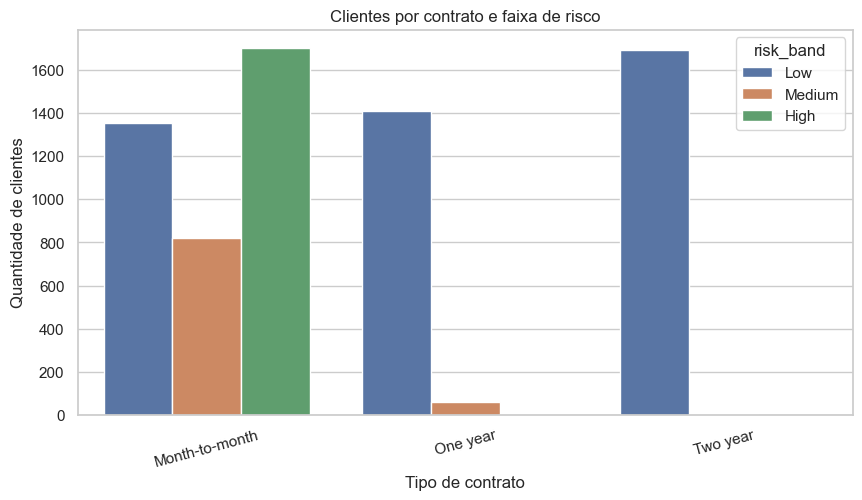

In [6]:
contract_risk = (
    df.groupby(["Contract", "risk_band"], observed=True)
    .size()
    .reset_index(name="customers")
)

ax = sns.barplot(
    data=contract_risk,
    x="Contract",
    y="customers",
    hue="risk_band",
    hue_order=risk_order,
)
ax.set_title("Clientes por contrato e faixa de risco")
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Quantidade de clientes")
plt.xticks(rotation=15)
plt.show()

Esse recorte permite enxergar se algum tipo de contrato concentra mais clientes de alto risco. Se contratos mensais aparecerem com maior volume em `High`, isso reforça a ideia de que contratos curtos estão mais associados ao cancelamento.


## 7. Receita mensal em risco

Este bloco estima a receita mensal associada aos clientes de alto risco, segmentada por tipo de serviço de internet. Isso ajuda a priorizar onde uma ação de retenção pode proteger mais receita.


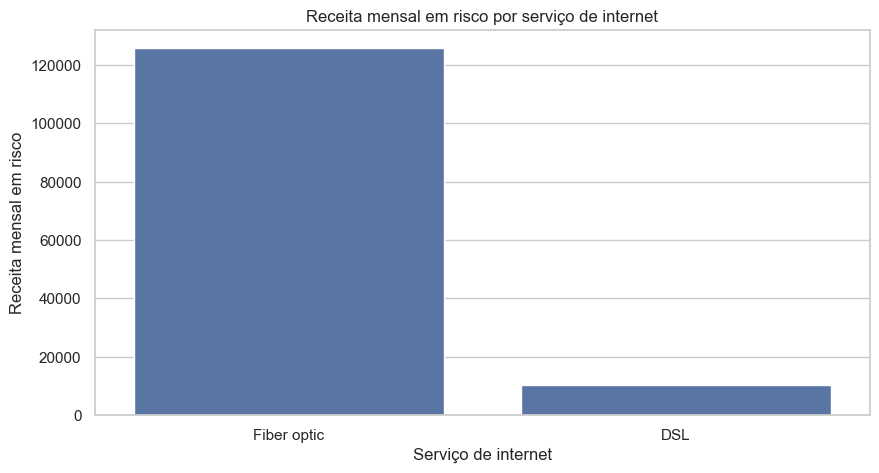

In [7]:
revenue_at_risk = (
    df[df["risk_band"] == "High"]
    .groupby("InternetService", observed=True)["MonthlyCharges"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

ax = sns.barplot(data=revenue_at_risk, x="InternetService", y="MonthlyCharges")
ax.set_title("Receita mensal em risco por serviço de internet")
ax.set_xlabel("Serviço de internet")
ax.set_ylabel("Receita mensal em risco")
plt.show()

Esse gráfico transforma risco em impacto financeiro. Em vez de olhar apenas a quantidade de clientes em `High`, ele mostra onde está concentrada a mensalidade dos clientes de maior risco, ajudando a priorizar ações com maior potencial de proteger receita.


## 8. Clientes prioritários

Por fim, vamos listar os clientes com maior probabilidade de churn. Essa tabela pode servir como base para uma ação direta de retenção.


In [8]:
top_customers = (
    df.sort_values("churn_prob", ascending=False)
    [[
        "customerID",
        "churn_prob",
        "risk_band",
        "recommended_action",
        "Contract",
        "tenure",
        "MonthlyCharges",
        "InternetService",
        "PaymentMethod",
    ]]
    .head(20)
)

top_customers

,customerID,churn_prob,risk_band,recommended_action,Contract,tenure,MonthlyCharges,InternetService,PaymentMethod
3380,5178-LMXOP,0.9497,High,Direct retention action,Month-to-month,1,95.10,Fiber optic,Electronic check
4800,9300-AGZNL,0.9482,High,Direct retention action,Month-to-month,1,94.00,Fiber optic,Electronic check
1976,9497-QCMMS,0.9481,High,Direct retention action,Month-to-month,1,93.55,Fiber optic,Electronic check
1410,7024-OHCCK,0.9466,High,Direct retention action,Month-to-month,2,93.85,Fiber optic,Electronic check
6368,2720-WGKHP,0.9463,High,Direct retention action,Month-to-month,2,94.00,Fiber optic,Electronic check
3749,4424-TKOPW,0.9462,High,Direct retention action,Month-to-month,2,93.85,Fiber optic,Electronic check
5989,5567-WSELE,0.9454,High,Direct retention action,Month-to-month,3,94.60,Fiber optic,Electronic check
3159,5150-ITWWB,0.9442,High,Direct retention action,Month-to-month,3,94.85,Fiber optic,Electronic check
6866,0295-PPHDO,0.9440,High,Direct retention action,Month-to-month,1,95.45,Fiber optic,Electronic check
2745,4826-XTSOH,0.9432,High,Direct retention action,Month-to-month,1,86.05,Fiber optic,Electronic check


Essa tabela é a parte mais acionável da análise. Ela lista os clientes com maior probabilidade de churn e traz informações úteis para decidir quem abordar primeiro e qual contexto considerar antes de uma ação de retenção.
